- вибрати дані для класифікації бінарної (спочатку синтетичні)
- показати їх
- загрузити їх
- трейн і тест для х та у

In [ ]:

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import pandas as pd
import numpy as np

In [2]:
X_simple, y_simple = make_classification(
    n_samples=500,
    n_features=2,          # 👈 важливо! для візуалізації
    n_informative=2,
    n_redundant=0,#?
    n_clusters_per_class=1,
    class_sep=1.5,         # 👈 наскільки легко розділити
    flip_y=0.04,
    random_state=42
)
type(X_simple), X_simple.shape, y_simple.shape  

(numpy.ndarray, (500, 2), (500,))

In [3]:
X_simple[:5]

array([[ 0.75682995, -1.09912807],
       [ 2.37384662, -3.96976419],
       [ 2.28730337, -3.00222426],
       [ 1.69668341, -1.13445852],
       [ 2.77894589,  2.33784428]])

In [4]:
np.unique(y_simple)

array([0, 1])

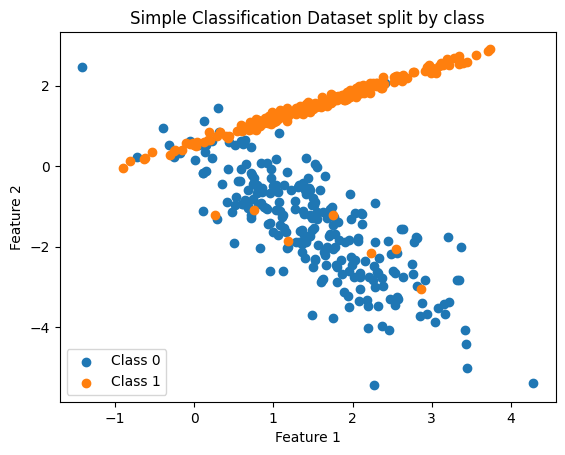

In [5]:
# plt.plot(X_simple[:, 0], X_simple[:, 1], 'o')
plt.figure()

for cls in np.unique(y_simple):
    plt.scatter(
        X_simple[y_simple == cls, 0],
        X_simple[y_simple == cls, 1],
        label=f"Class {cls}"
    )
plt.title("Simple Classification Dataset split by class")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

In [6]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple =  train_test_split(
    X_simple,
    y_simple,
    stratify=y_simple, # зберігаємо пропорції класів у вибірках
    random_state=42,
)


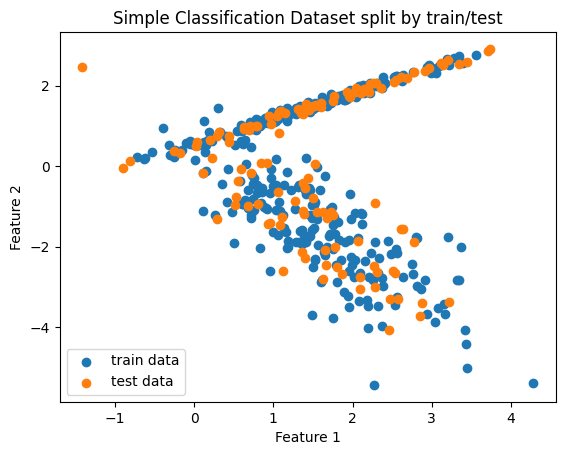

In [7]:
plt.figure()

for t, d in {'train': X_train_simple, 'test': X_test_simple}.items():
    plt.scatter(
        d[:, 0],
        d[:, 1],
        label=f"{t} data"
    )
plt.title("Simple Classification Dataset split by train/test")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

In [8]:
y2d = y_simple.reshape(-1, 1)
df_y = pd.DataFrame(y2d, columns=['target'])
print('Check if class is balanced')
df_y.value_counts()

Check if class is balanced


target
1         254
0         246
Name: count, dtype: int64

Шо на цьому етапі робив тіп
1. Тоже згенерив датасет так само
2. сплітнув
3. дф intro_frame весь і мітки як в оригіналі (нашо???) для візуалізації??
4. дф split_frame те саме, але спочатку трейн а потім тестові + колонка з тим чи тестові чи ні
5. дф balance_frame де просто кількість класів - перевірка чи збалансований

6. просто показав, як працює сигмоїд?

7. просто показав, я працює кросентропія?

8. знов генерить штучні дані
9. сплітить
10. просто виводить показуючи різними кольорами класи

11. створює пайплайн 

In [16]:
logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000)),
    ]
)

12. фітить

In [17]:
logreg.fit(X_train_simple, y_train_simple)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

13. предіктить мітки і ймовірності (нашо другі і чому лише один клас??)

In [20]:
pred = logreg.predict(X_test_simple)

14. юзає свій метод для метрик

In [22]:
print(f"accuracy: {accuracy_score(y_test_simple, pred)}\nprecision: {precision_score(y_test_simple, pred, zero_division=0)}\nrecall: {recall_score(y_test_simple, pred, zero_division=0)}\nf1: {f1_score(y_test_simple, pred, zero_division=0)}")

accuracy: 0.928
precision: 0.921875
recall: 0.9365079365079365
f1: 0.9291338582677166


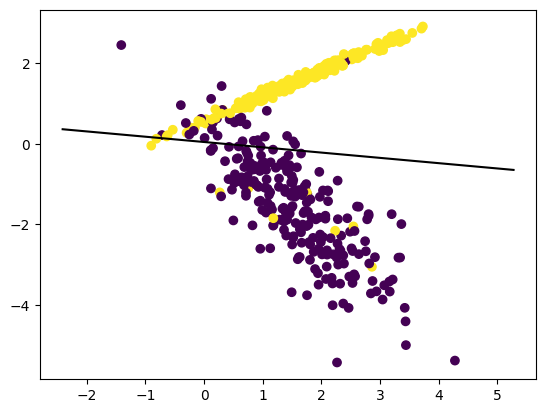

In [26]:
w = logreg.named_steps["model"].coef_[0]
b = logreg.named_steps["model"].intercept_[0]

# сітка точок
x_min, x_max = X_simple[:, 0].min() - 1, X_simple[:, 0].max() + 1
y_min, y_max = X_simple[:, 1].min() - 1, X_simple[:, 1].max() + 1


x_vals = np.linspace(x_min, x_max, 100)
y_vals = -(w[0] * x_vals + b) / w[1]

plt.scatter(X_simple[:, 0], X_simple[:, 1], c=y_simple)
plt.plot(x_vals, y_vals, 'k')
plt.show()